## Ensemble Learning


We have bunch of supervised learning algorithms called **Ensemble Learning** which is used for both classificaition and regression problems. We use these modells especially when we have table-like data(Each row is an instance/sample, and each column is a feature/attribute and the last column is often the label/target if it's supervised learning.). The idea of ensemble learning is that while individual models may make errors, combining their predictions in a smart way can lead to higher accuracy and more robust results.

These models could be All the same type (e.g., many decision trees) or a mix of different models(e.g., combining SVM, logistic regression, and decision trees).

The final output is usually decided by **voting** (for classification) or **averaging** (for regression)

Everything starts from **Condorcet's jury theorem**.

##### Condorcet's jury theorem:

What this theorem says is basically this: 

Consider we have *N* voters wish to reach to a decision by *majority vote*. Each voter has an **idependent** probability *p* of voting for the correct decision. Let *M* be the probability of the majority voting for the ccorrect decision, The theorem is:

$$\text{If} \; p > 0.5 \; \text{and} \; N \rightarrow \infty \text{, then} \; M \rightarrow 1$$

How?

> Not very familiar with it's math I will get back to proving it later :))



#### Ensemble Learning

Now how do we generalize this theorem to ML and having better prediction models:

We use this theorem and we think that why should we only train one model everytime, we can instead train *M* models and consider that each of those model's probabilities of making a true choice given a sample is a bit higher than 0.5.

Now consider that we have bunch of **weak learners** or small models that each of them predict a bit better than *random* and we train each of them independantly(we try our best) and after that we do majority voting among them and considering the theorem explained above if the number of these weak models get big enough we would get the true prediction by the majority vote by the models. 

The above explanations is the core idea of the ensemble learning. Let's get much deeper in it:

We have two types of learners considering their strength of predicting:

+ **Strong learner:** So far we were digging these learners up, we have had only one model and we trained that model and all the deccisions and predictions was made by that specific trained model. And for these models the classification error can be made arbitrary small.

+ **Weak learner:** A classifier that are kind of like having the strength of flipping a coin but a bit better, and are better than *random* guessing(For ensemble learning we will be using bunch of these and the majority voting between them.)

> Weak learners get underfit or overfit most of the times and we try to avoid thesee problems using ensembled learning.

> Typically weak learners have **high bias** and **low variance** but it is not a very strict rule as we know we're going to have an ensembled learner combining multiple decision trees which has a **low bias** and **high variance**, but just typically and generally saying we're trying to make a better model in terms of bias and variance using some weak models that have a bad bias or a bad variance.


Note: Bias and Variance thus inversely represent model accuracy on training and test data respectively.

##### Ensemble Methods:

Clearly we have bunch of methods for these Ensebmle learnings, these methods can be **parallel** or **sequential**.

+ **Parallel**: In these methods bunch of weak learners gets trained in parallel and the no weak learner waits for other weak learner's process, and the basic motivation to this method is to use **independence** between the learners.


+ **Sequential**: We first train a model, and we observe and note which part it worked good and which part it worked bad and for which samples it is not predicting wrong, and then we make the subsequent model that is gonna be train to focus on the group that our previous model could not predict well enough while training, It is kind of like that we make the add more weight to that group of sampples and decrease the weight of the other group(which previous model predicted well), so our subsequent model focus more on that group of samples and this goes on 'till the *M*th model and we hope that the *M*th model predict samples very well. 

Question: Now sequential in the voting process and after all models have been trained how do we do the *majority voting* is it like having a weighted consideration for later-trained models (cause they are hopefully predicting better) or no we give an equal importace to all of our models? 
    
+ It is obviously the weighted approach we're gonna have for the majority voting. 'Cause from the theory we now later-trained models have more accuracy than earlier-trained ones and those with better accuracy have more importance for the *majority voting*.

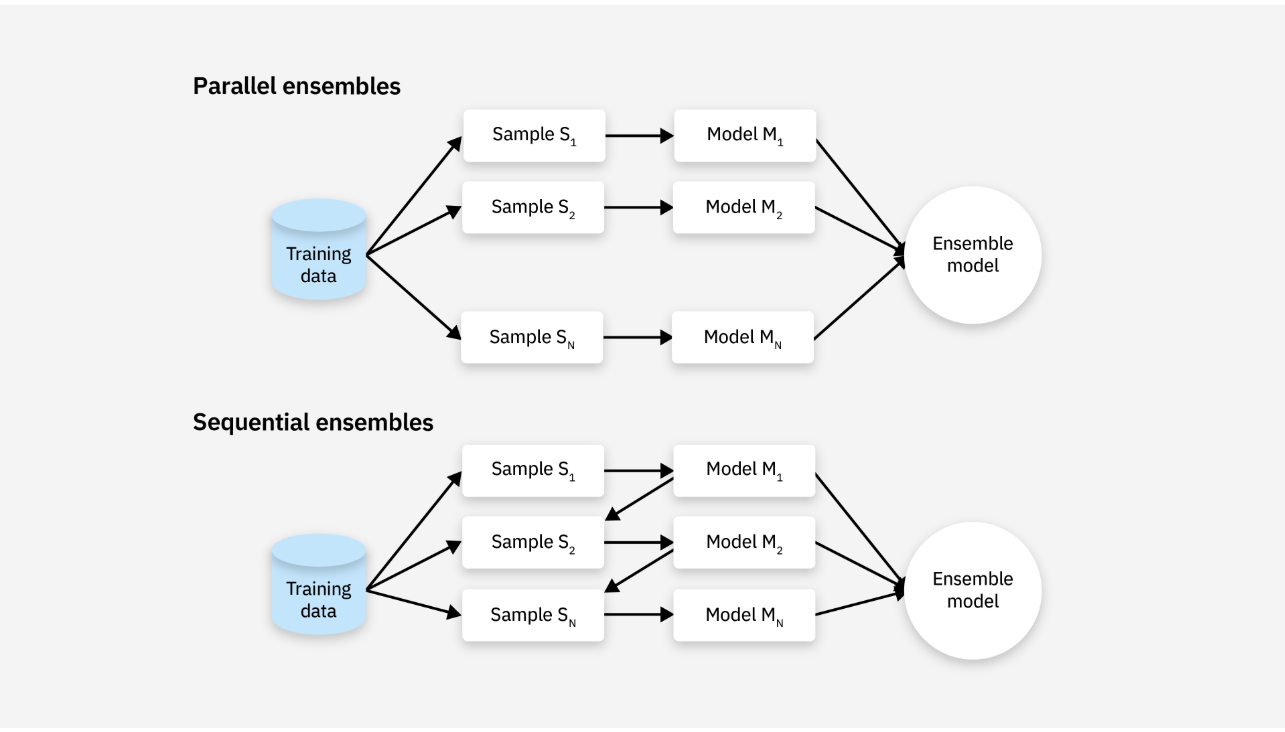
<center>Figure 1: Parallel and Sequential ensembles(IBM)</center>

<br>
<br>

> "Parallel methods are further divided into homogenous and heterogenous methods. Homogenous parallel ensembles use the same base learning algorithm to produce all of the component base learners. Heterogenous parallel ensembles use different algorithms to produce base learners."  
> — [IBM Think: Ensemble Learning](https://www.ibm.com/think/topics/ensemble-learning)

Prrallel method has divides into two category:

+ **Homogenous**: 

    These parallel methods use the same base learning algorithm to produce all of the component base learners.<br>
    It's purpose is to reduce variance and get to a more stable and consistent predictions.<br>
    Goal: These ensembles rely on the fact that simple models trained differently can disagree slightly.<br>
    The point is that the diversity here comes from the data they are trained on(bootstrap samples) and not the algorithm.

+ **Heterogenous**:

    These types of parallel methods combine strengths of different algorithms, each of which sees the data in a different way.<br>
    The goal is to reudce both bias and varaince by leveraginb diversity in model behavior.




### Bagging:

+ **Definition**:

    The word `Bagging` stands for Bootstrap Agreegation, It uses **bootstrap resampling** to generate different training datasets from original training dataset.
    Bagging is a *homogenous* parallel method. Bagging train weak learners based on each bootstrap samples, and during **testing** , it **aggregates** the weak learners by uniform averaging or majority voting.

+ **Bootstrap Resampling**:

    This method derive multiple **new** datasets from one **initial** training dataset in order to train multiple base learners. How it works? Say a training dataset contains *m* training examples. Bootstrap resampling copies *n* data instances from that set into a new subsample dataset, with some initial instances appearing *more than once* and others exluded entirely. These are bootstraping samples. Repeating this process *x* times produces *x* iterations of original dataset, each containing *n* samples from the initial set. Each iteration of the initial set is then used to train a separate base learner with the **same learning algorithm**.

<br>

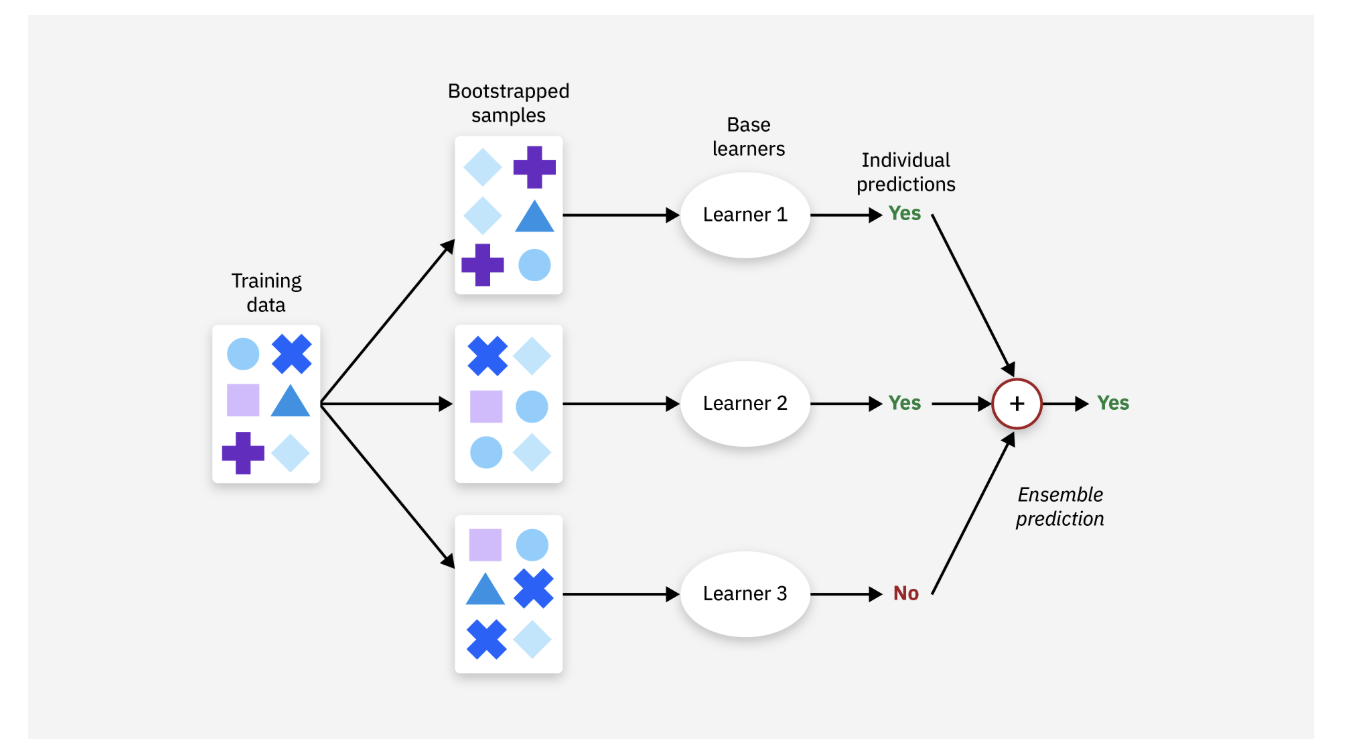
<center>Figure 2: Bagging Method(IBM)</center>

<br>
<br>

+ **Algorithm**:

    1: **Input** *M* (required ensemble size), $D = \{(x^{(1)}, y^{(1)}), ..., (x^{(N)}, y^{(N)})\}$ (training set)<br>
    2: **for** $t = 1$ to $M$ **do**<br>
    3: &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Build a dataset $D_t$ by sampling $N$ items randomly with replacement from $D$ (*Bootstrap resampling: lke rolling N-face dice N times*).<br>
    4: &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Train a model $h_t$ using $D_t$ and add it to the ensemble<br>
    5: **end for**<br>
    6: $H(x) = sign(\sum_{t=1}^{M} h_t(x))$ (Aggregate models by voting for classification or by averaging for regerssion)<br>


##### Bias-Variance Discussion:

+ What is the bias-variance status of a weak learner in bagging?

    In bagging(like in a Random Forrest), the weak learners are usually **high variance**, **low bias** models(like fully grown decision trees). That maens:
    + The model can fit **training data** **well**(that gives us our low bias).
    + But it is **very sensitive** to training data changes(that gives us our high variance)
    + So its **test** accuracy fluctuates alot which means that it can overfit very easily

+ What happens when we aggregate many of these in bagging?

    **Bias** stays roughly the same, cause all models are complex enough to fit the training data well individually. But the **variance** **decreases significantly**, cause averaging smooths out the fluctuations(random errors) of individual models.

> So with the above discussions we know that for solving the **high variance** problem one of our good options is *Bagging**. And it will be use when we've got unstable modles which change a lot if data changes(high variance) and when we want to reduce overfitting.



#### Decision Tree(DT):

Decision Trees (DTs) are a non-parametric supervised learning method used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. A tree can be seen as a piecewise constant approximation.

<br>


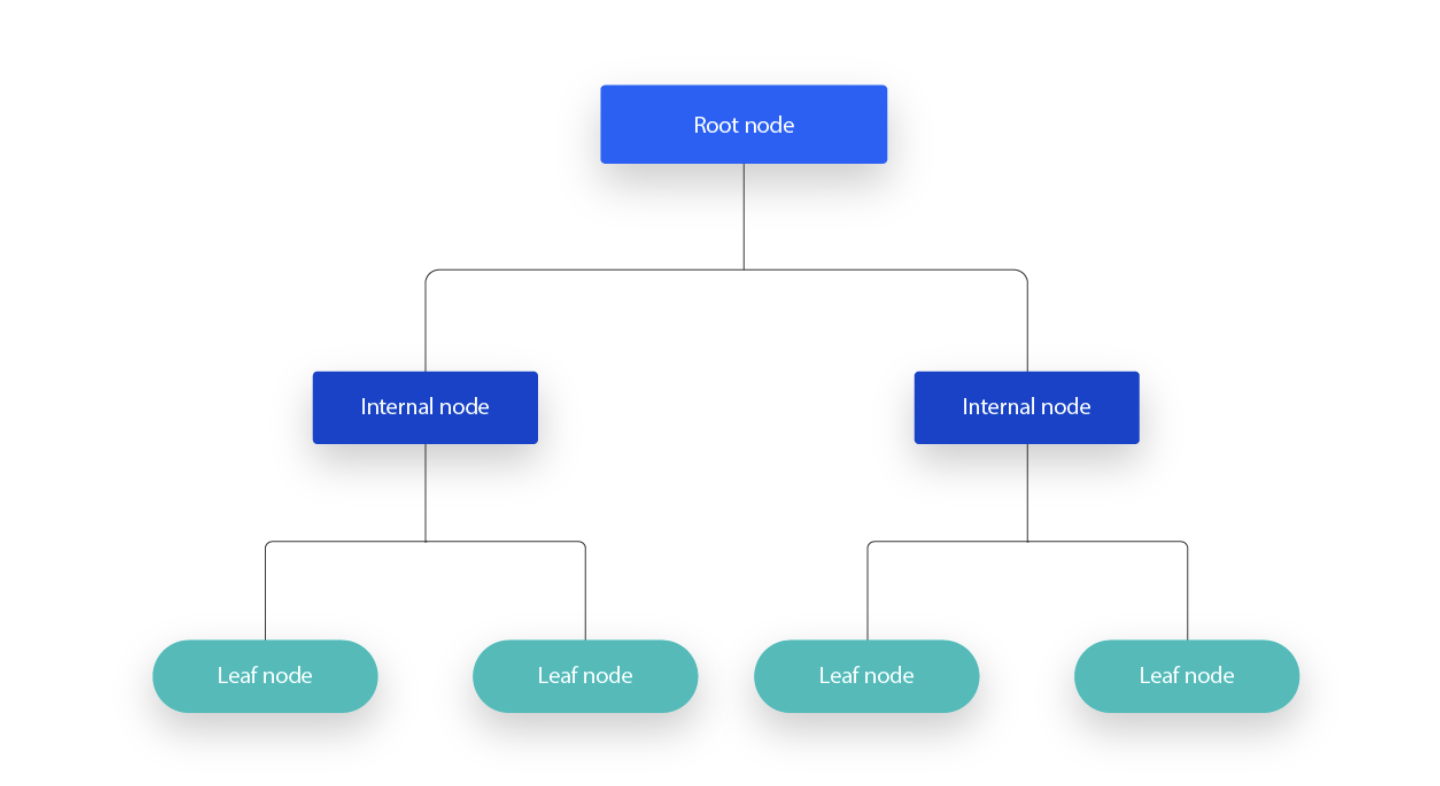
<center>Figure 3: Analogy of a DT(IBM)</center>

<br>

> Each **internal node** denotes a test on an attribute.

Learning an optimal DT is **NP-complete**, so instead, we use a **greedy search** based on a **heuristic** and we can't guarantee to return the globally-optimal decision tree. And the most common strategy for DT learning is a greedy top-down approach.

Tree is constructed by splitting samples into subsets based on an **attribute value test** in a recursive manner.

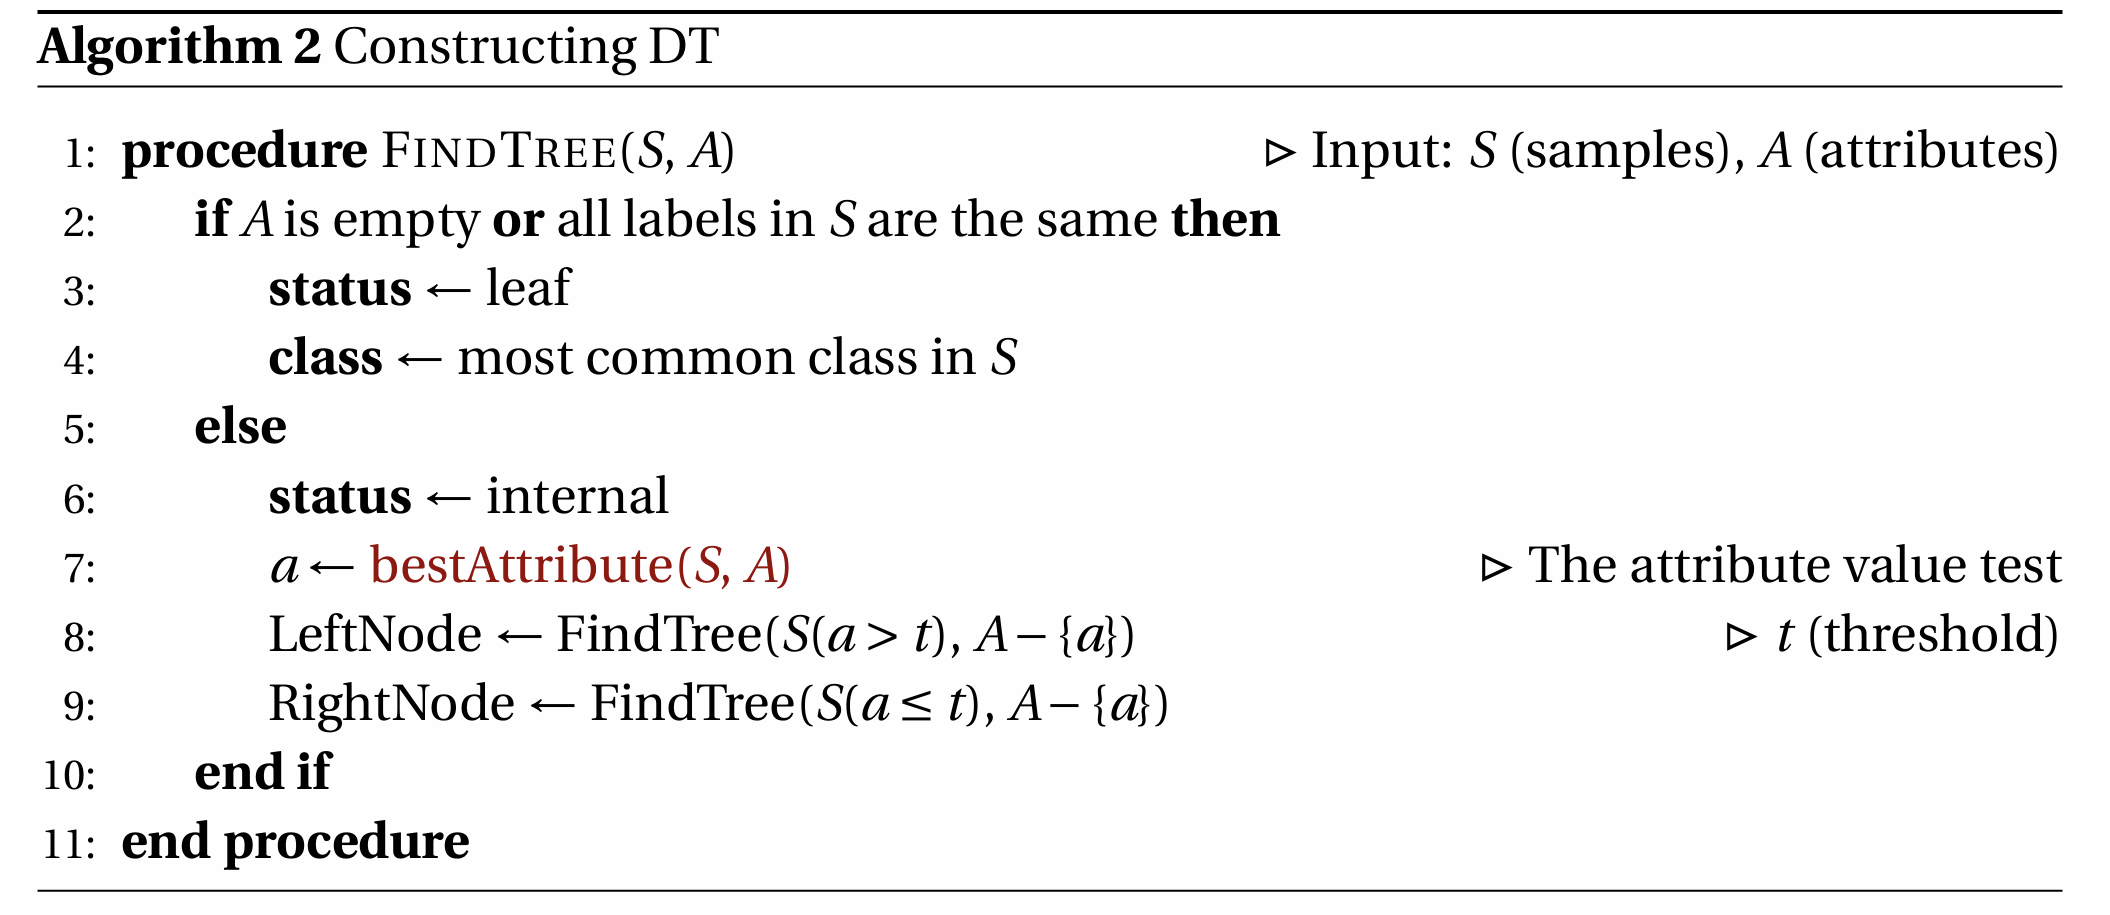
<center>Figure 4: DT algorithm(Ensembled slides)</center>


Now for choosing the best attribute to split on, we should have metrics to quantify the split's quality for this purpose we have **Information gain** and **Gini-index** methods:

First we should explain **Entropy** and the calculation way for it cause its going to be used in the **Information gain**

+ **Entropy**: Measures the uncertainty in a specific distribution:

    $$H(X) = -\sum_{x_i \in x} P(x_i)\log{P(x_i)}$$

    This will show how distributed a set of data is. The lower it is the better split have happened on it.

+ **InformationGain**:

    $$Gain(S, A) = H_S(Y) - \sum_{V \in values\{A\}} \frac{|S_v|}{|S|} H_{S_{V}}(Y)$$

    + $A$: Variable to split samples
    + $Y$: target variable
    + $S$: samples, $S_V$: subset of $S$ where $A = V$
    + $H_S(Y)$: entropy of $Y$ over $S$

    The bigger the information gain is the better the feature to split at that depth and noe.

> Now as previously mentioned we know that decision tree can have low bias and high variance and can get overfit very easily by facing with different data, So for solving this problem we tend to use ensembled learning with decision trees as base models which we call this method **Random Forrest**

### "Independenlty and Identiccally Distributed (i.i.d)"

In ML we here the term above alot when dealing with models and data. We wanna see what this term even mean:

+ **Identically Distributed**:

    All data points come from the same probability distribution. Meaning no part of data is from a different **population**.

+ **Independently Distributed**:

    Each data opint is **not dependent** on the others. No information about one sample tells you anything about another.

So i.i.d = :

> All samples are from the same distribution, and are independent of each other.

Why it is important in ensemble learning?
1. Each model sees a different random sample of the same data distribution
2. Errors made by each model are uncorrelated

#### Random Forrest:

First of all let's answer this question that why use bagging on decision trees?
Why use DT as base model in bagging:
+ Interpretable
+ Robust to outliers
+ Low Bias
+ High variance

DTs are good candidates as base models cause if we consider many(nearly) unbiased tree estimators, leads to bias remains similar, but variance is reduced.

Now let's get the solution to our problems: **Random Forrest**:

+ **Definition**: The Random Forrest algorithm is an extension of the bagging method as it utilize both bagging and feature randomness to create an **uncrollated** forest of decision trees.

**Feature Randomness**:Feature randomness generates a random subset of features, which ensures low correlation among decision trees. This is a key difference between decision trees and random forests. 

To explain this in easier terms:

We have a new hyperparameter `m` in random forrests which indicates that it splits the features into some (number of decision trees) feature subsets randomly and give each of them as training features to each decision tree that we got and then we will see that our ensembled learner of the aggregated decision trees with diffrent trainingn features have a broader and a multifaceted perspective of our data and thus the variance of the final ensembled model would be much lower than a single decision tree and the predictions would become much more better.


> We also bootstrap our training data samples (just for a reminder)

> This method also helps in finding a non-linear decision boundry for our data samples.
<br>

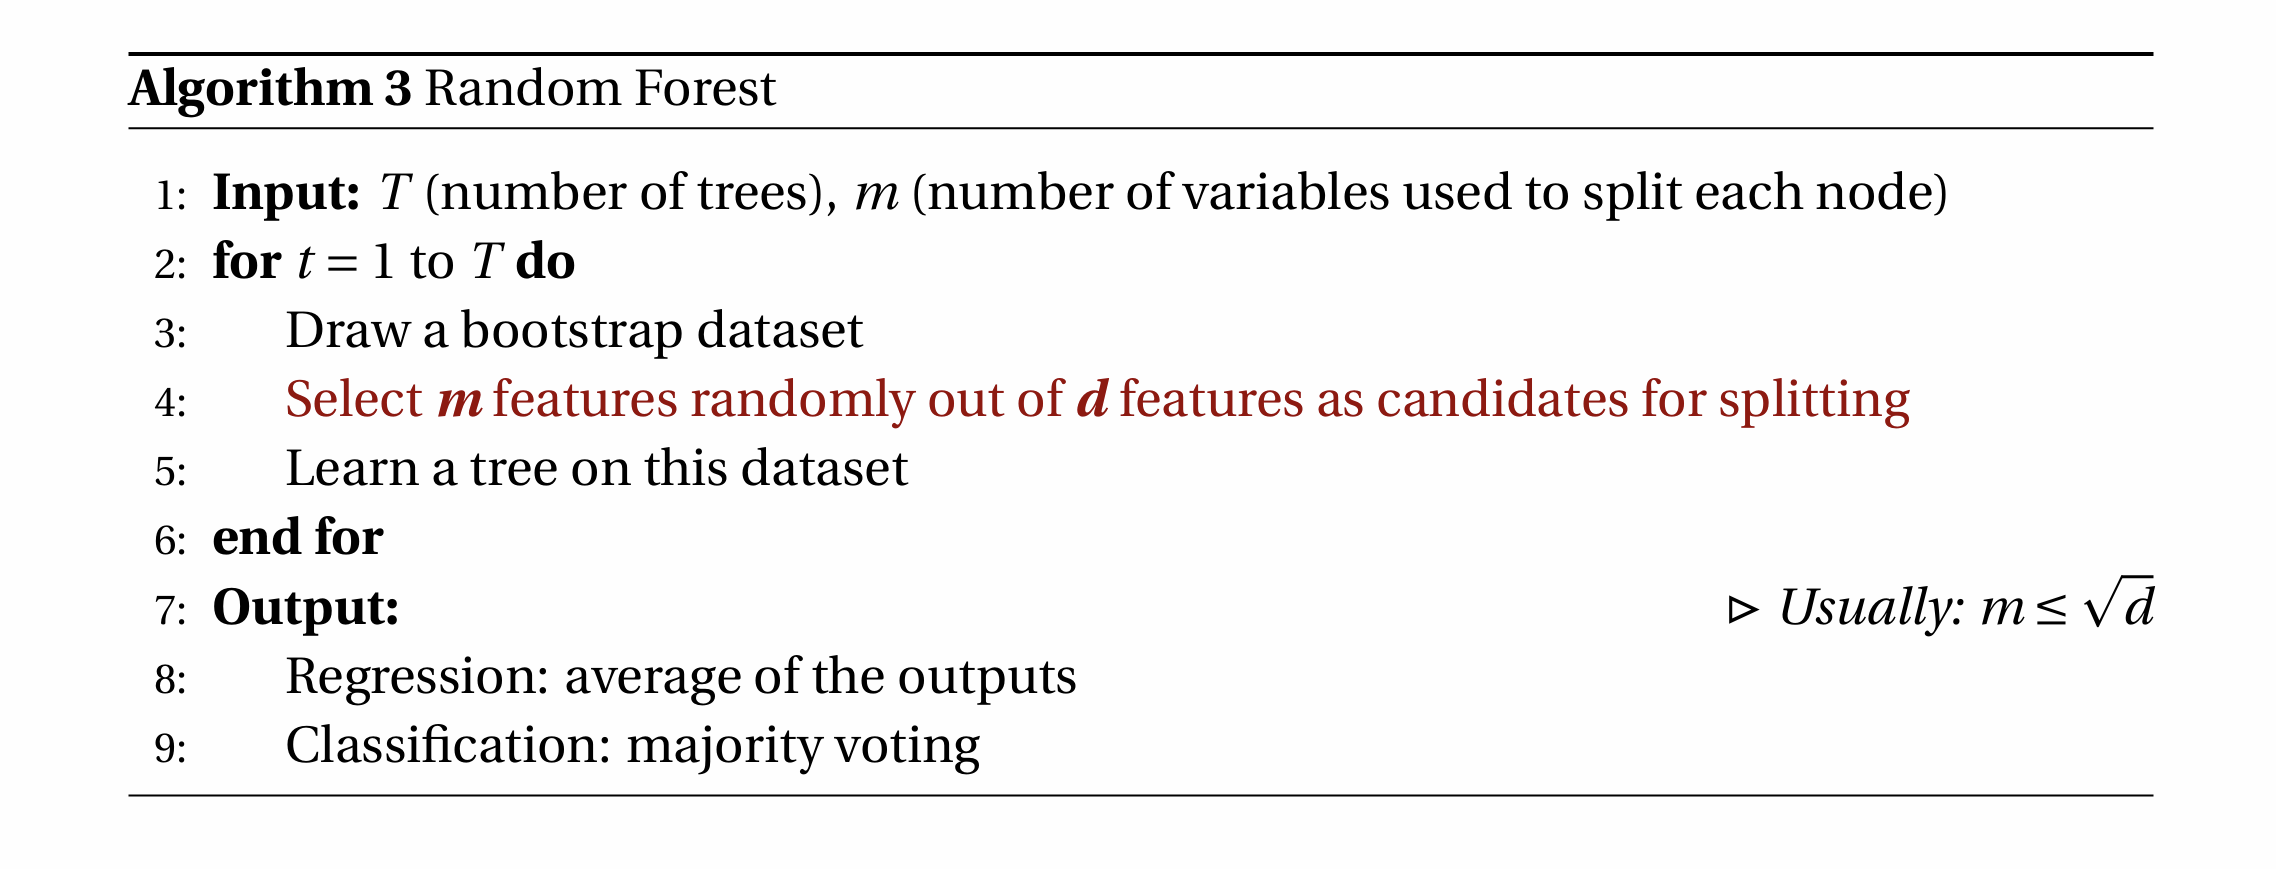
<center>Figure 5: Random Forrest Algorithm(Ensembled slides)</center>
<br>

<br>

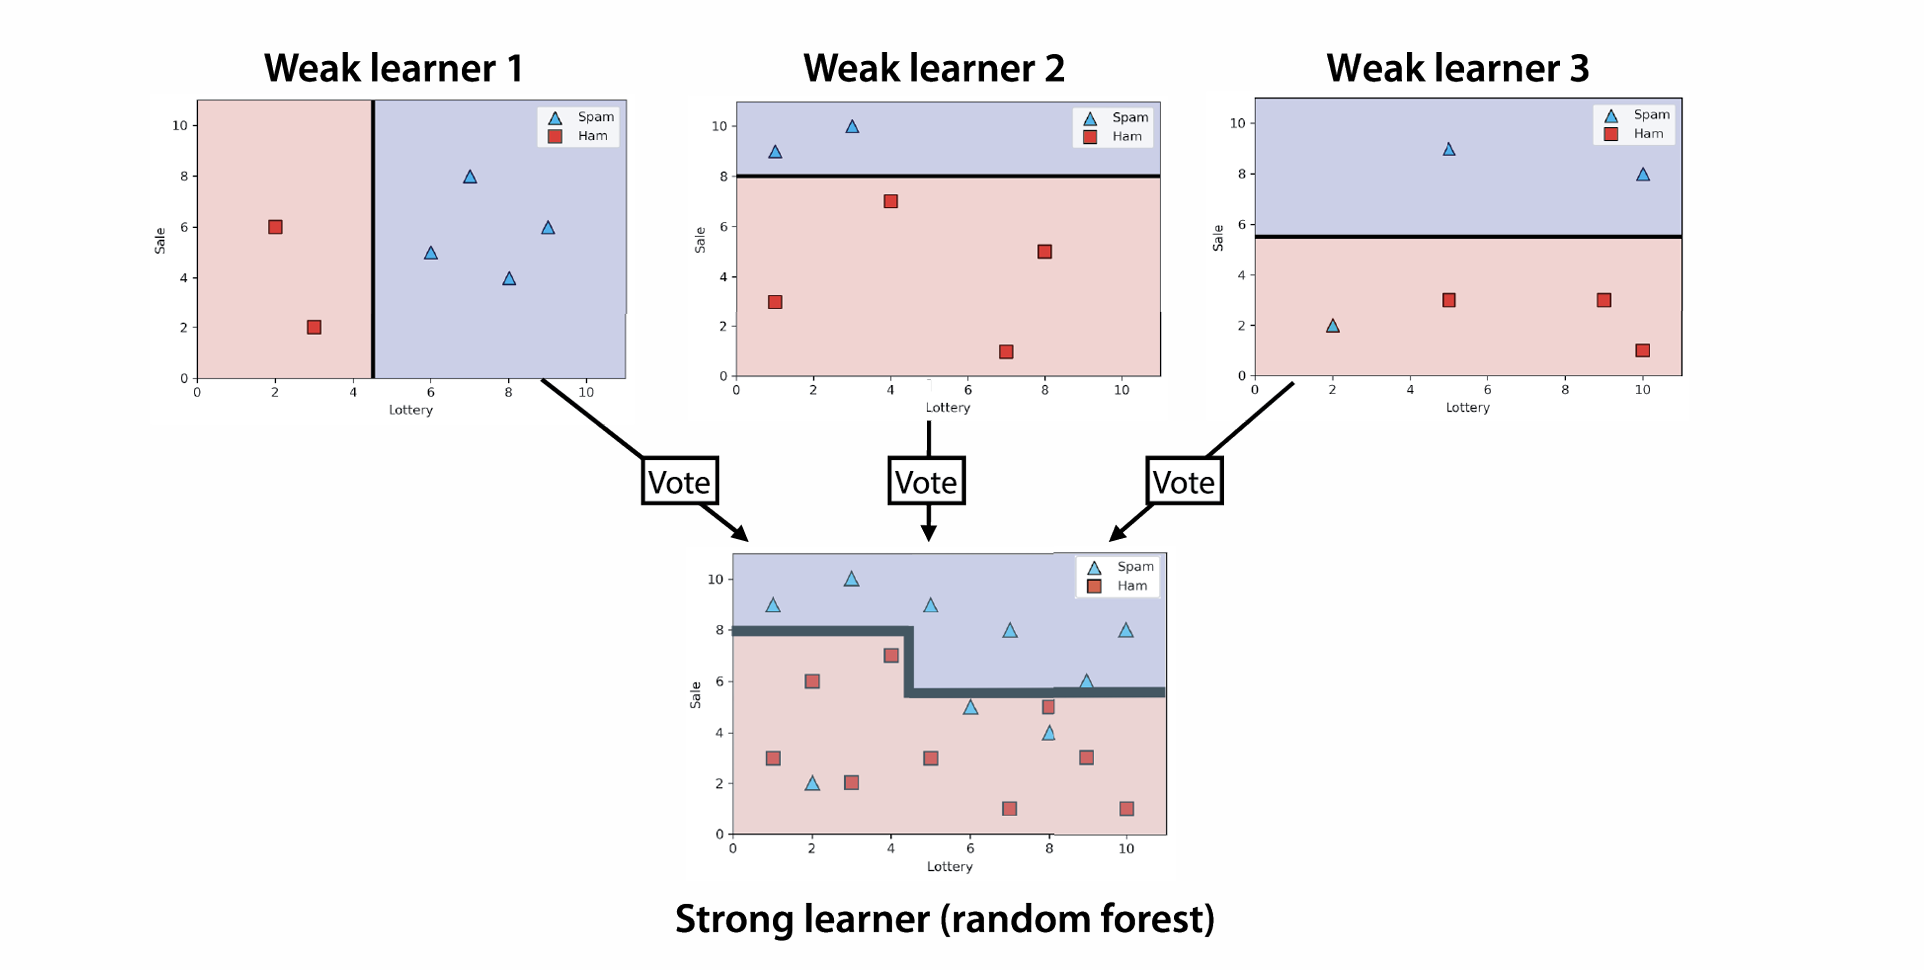
<center>Figure 6: Random Forrest example(Adapted from [?])</center>
<br>

> In the figure above you're able to see bunch of decision trees has been trained on bootstrapped data samples and subsets of features and for the ensembled model their majority vote was considered as the decision boundary of the final model

> The strength  of the random forrest is in the ability of it to give us a non-linear **decision boundary**

### Boosting:

Boosting algorithms are a **sequential** ensemble method. Boosting has many variations, but they all follow the same general procedure. Boosting trains a learner on some initial dataset, *d*. The resultant learner is typically weak, misclassifying many samples in the dataset. Much like bagging, boosting then samples instances from the initial dataset to create a new dataset($d_2$). Unlike bagging, however, boosting prioritize misclassified data instances from the first model or learner. A new learner is trained on this new dataset $d_2$. Then a third dataset($d_3$) is often compiled from $d_1$ and $d_2$ disagree. The process repeats *n* times to produce *n* learners. Boosting then combines and weights all the learners together to produce final predictions.

<br>


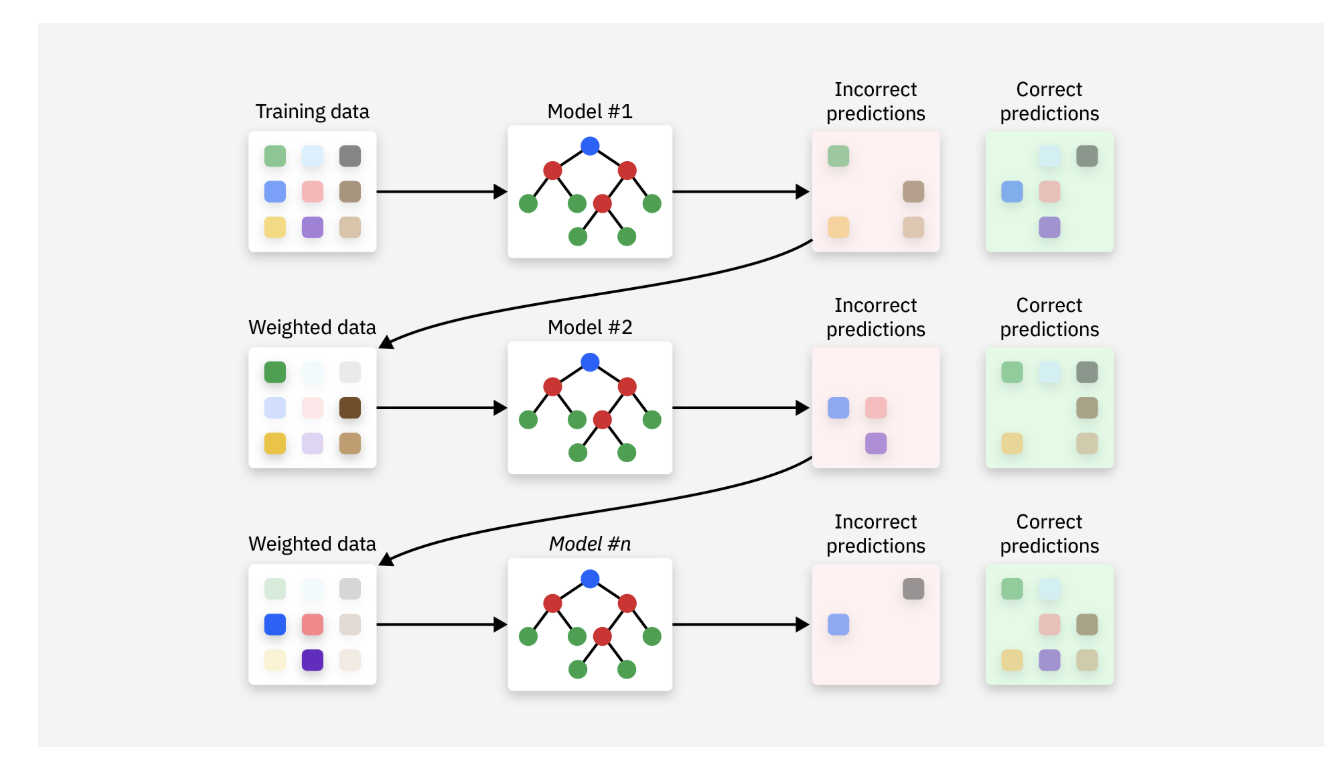
<center>Figure 7: Boosting a sequential ensembled learning method(IBM)</center>

<br>

In the train process of boosting, if one model does not perform well on bunch of samples, those samples are known as misclassified samples, and when we wanna pass our data samples to the next base leaner we add some weight (importance) to misclassified samples and decrease some weight from those where classified right in the previous model and this routine will goes on till our base models finishes.  

> In this method the weak learners are each other's complementary. They would have "expertise" on different subsets of the dataset. So they would work better on different subsets.

Long story short it's idea is that if we train our data on multiple models that each would classify and predict a part of that data by summing all their predictions with a weight for importance of each model's prediction and if the number of the models was big enough we would definitely predict the right class.

So for finding a **strong** learner we combine bunch fof **weak** learners:

$$H_M(x) = \alpha_1 h(x;\theta_1) + ... + \alpha_M h(x;\theta_M)$$

+ $H_M(x)$: Is the final strong learner made by the weighted sum of weak learnerss = $h_i(x)$
+ $h(x;\theta_i)$: Is a weak learner model
+ $\theta_i$: Is the weak learner's parameters
+ $x$: Is the input data
+ $\alpha_i$: Is **Voting Power**: which determines the power or importance of a weak model's prediction.

Now for the final **prediction** we have:
$$\hat{y} = sign(H_M(x))$$

We have a candidate weak learner for boosting method:

**Decision Stumps**:

It's a binary classification algorithm. The idea of this model is very simple. "Only focus on one feature each time and find a point that can separate data the most". <br>
So each decision stumps classifier is based on only a single feature of $x$(e.g., $x_k$):
$$h(x;\theta) = sign(w_1x_k - w_0) \; , \theta = \{k, w_0, w_1\}$$

### AdaBoost

It is a sequentail and boosting method base algorithm that Iteratively add the classifier whose addition will be most helpful. In this algorithm we have bunch of weak learners that the train data to each one of them is weighted and their weight depends on if they've been misclassified or not in the previous weak learners and the importance of eacch weak learners in the whole model is determined by a weight (voting power) and by sum of all of these weak learners with their voting power help us make better predictions. And the purpose of the whole algorithm is that the weighted sum of misclassified samples get lower in each weak learner.

> Each weak learner is dependent on it's sprevious weak learner.

#### Algorithm

+ Our model is:
$$H_M(x) = \frac{1}{2} [\alpha_1 h_1(x) + ... + \alpha_m h_m(x)]$$

+ $\alpha_i$: Is **Voting Power**: Votes of the m-th weak learner
+ $h(x)_i$: Is a weak learner model
+ $\frac{1}{2}$: is for simplification in calculations later

$$\alpha_m = \ln{(\frac{1 - \epsilon_m}{\epsilon_m})}$$

+ And we've got an $w_m{(i)}$ which is the weight of sample $i$ in teration $m$:

$$w_{m+1}^{(i)} = w_{m}^{(i)} e^{\alpha_m I(y{(i)} \neq h_m(x^{(i)}))}$$

The $I(y{(i)} \neq h_m(x^{(i)}))$ determines that the model misclassified the sample for the equation works and the equation only calculate the misclassified smaples.

+ And we also have a loss function $J_m$ Which is the loss of the m-th weak learner:

$$J_m = \sum_{i=1}^{N} w_{m}^{(i)} \times I(\underbrace{y{(i)}}_{\text{True label}} \neq \underbrace{h_m(x^{(i)})}_{\text{label predicted by m-th weak learner}})$$

The $I()$ function is like an if, it works something like: $I(x > y)$ It's output will be 1 if realy $x > y$ otherwise 0 if $x \leq y$. It's called **Indicator** function.

+ We have also a $\epsilon_m$ which is the weighted error of the m-th weak learner.

$$\epsilon_m = \frac{\sum_{i=1}^{N} w_{m}^{(i)} \times I(y{(i)} \neq h_m(x^{(i)}))}{\sum_{i=1}^{N} w_{m}^{(i)}}$$

> $J_m$ is the **raw total weighted error** and $\epsilon_m$ is **Normalized weighted error. $J_m$ is useful when we want to compute an actual *cost* or *loss* using weights. $\epsilon_m$ is crucial for how much say the weak learner should have and determining whether a weak learner is better than random and it is for determining the $\alpha_m$.


If we look at the graph of the following equation for alpha(voting power):

$$\alpha_m = \ln{(\frac{1 - \epsilon_m}{\epsilon_m})}$$ 
$$\epsilon_m = 0.5$$
<br>

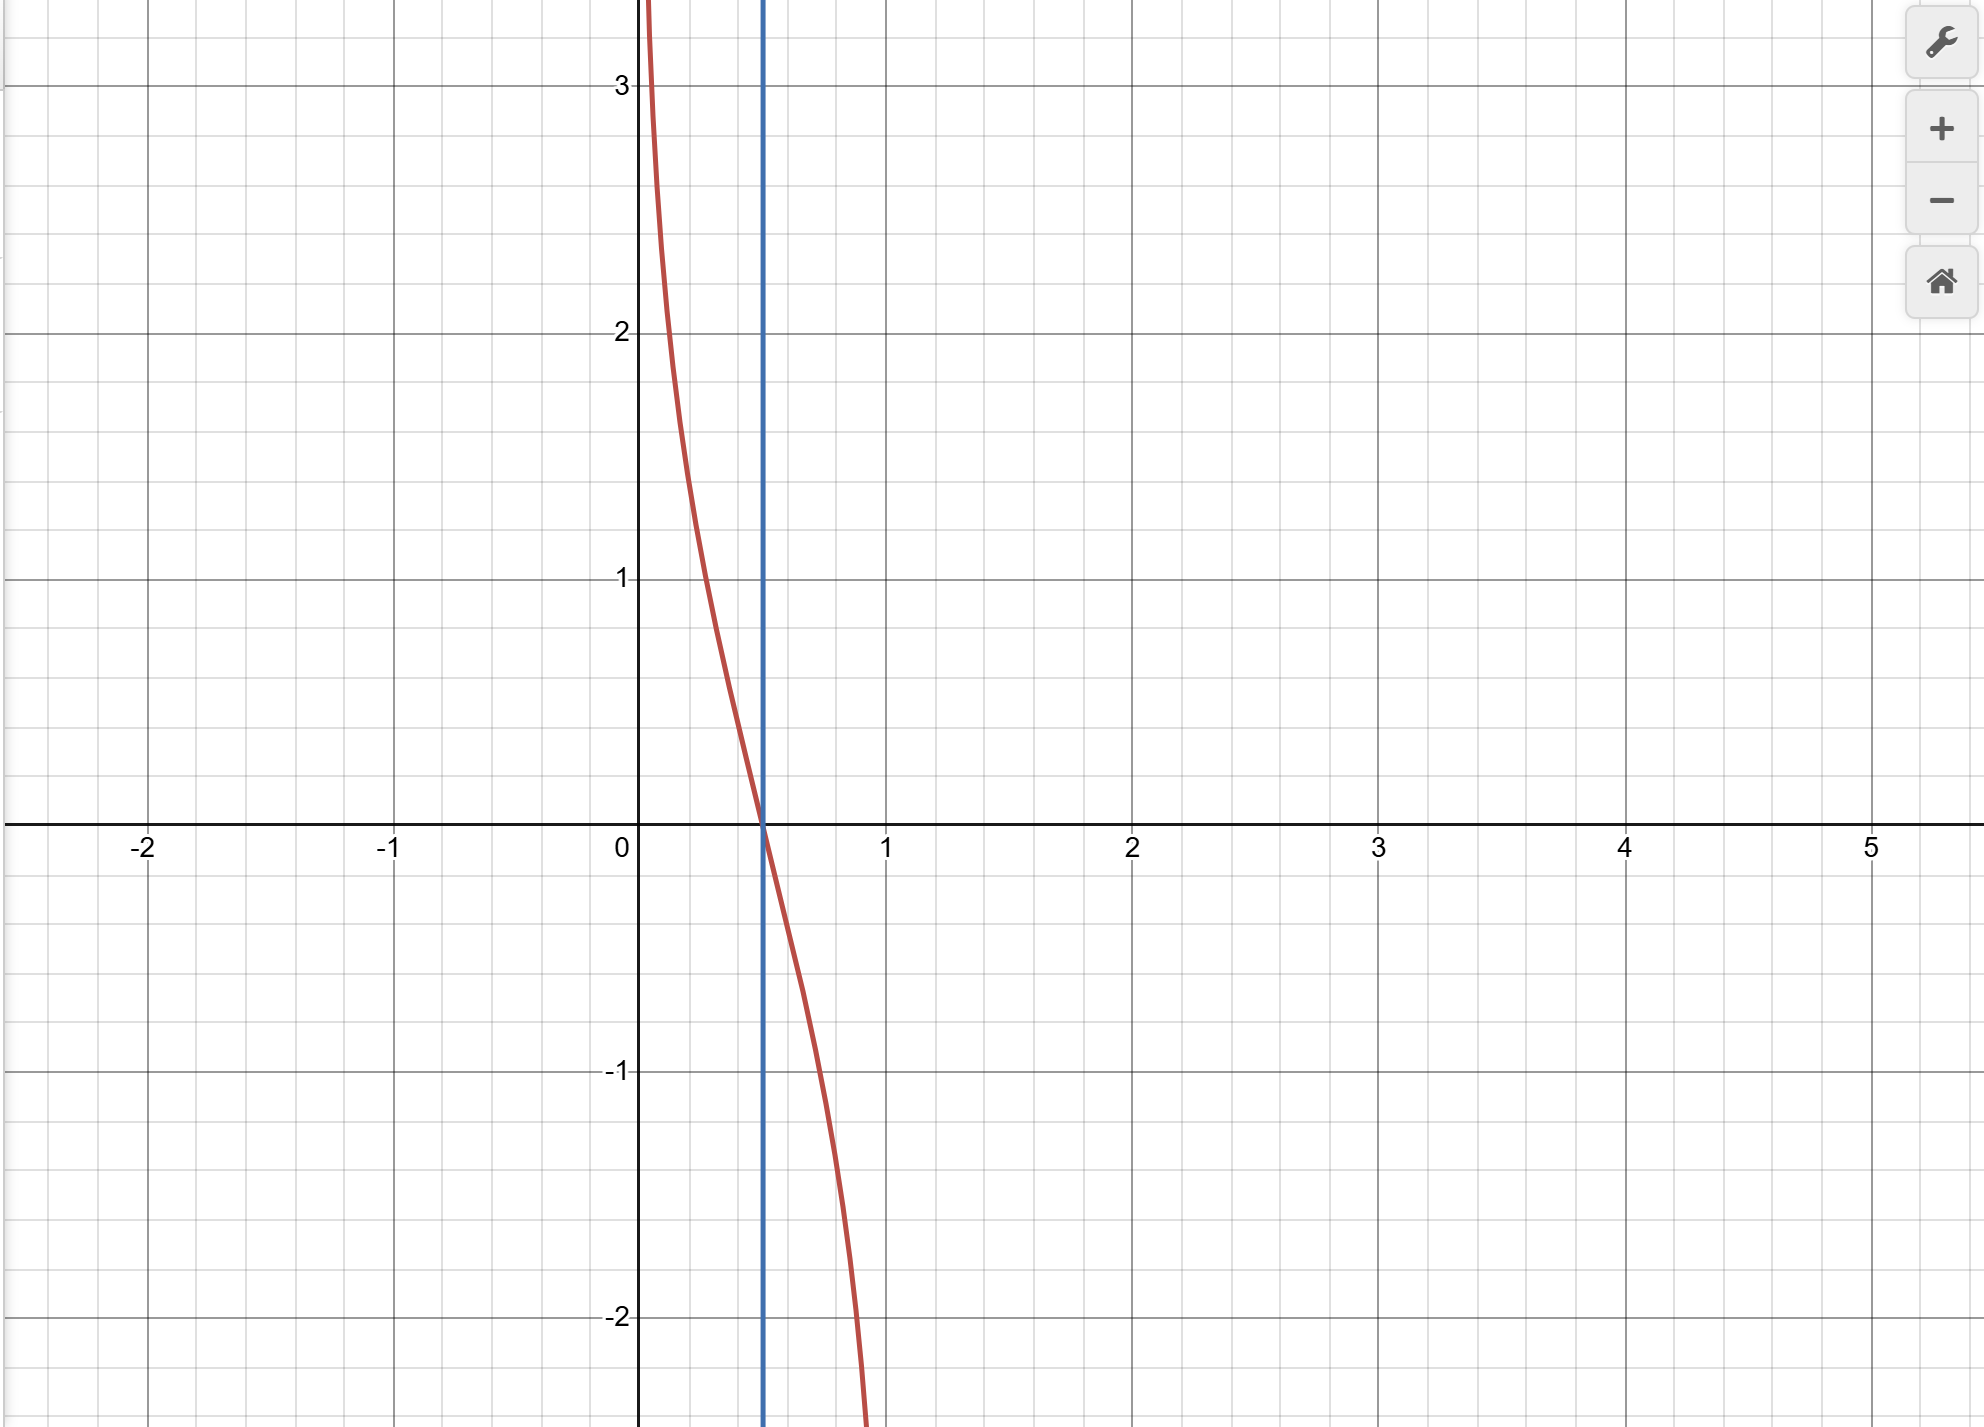
<center>Figure 8: Graph of the equations above</center>
<br>

> The red line is the alpha's function's graph and the blue line is where epsilon equals to 0.5.

We use alpha as the voting power parameter for each weak learner in our model and the value of it indicates the importance of the weak learner model's prediction. when epsilon is 0.5 it means that it has a random prediction behaviour and the model's predictions are not useful at all. and if the value of epsilon(the weighted error of teh m-th weak learner) was more than 0.5 it is said that the model's predictions are mostly wrong and would be a downful to our ensembled model and the value of it's voting power would become a minus number, and on the other hand if the value of weighted error(epsilon) be less than 0.5 it means that the model's predictions are better than random and as we get closer to the zero epsolon the voting power of the model increases and the importance of that model's prediction gets more important for the ensembled model.

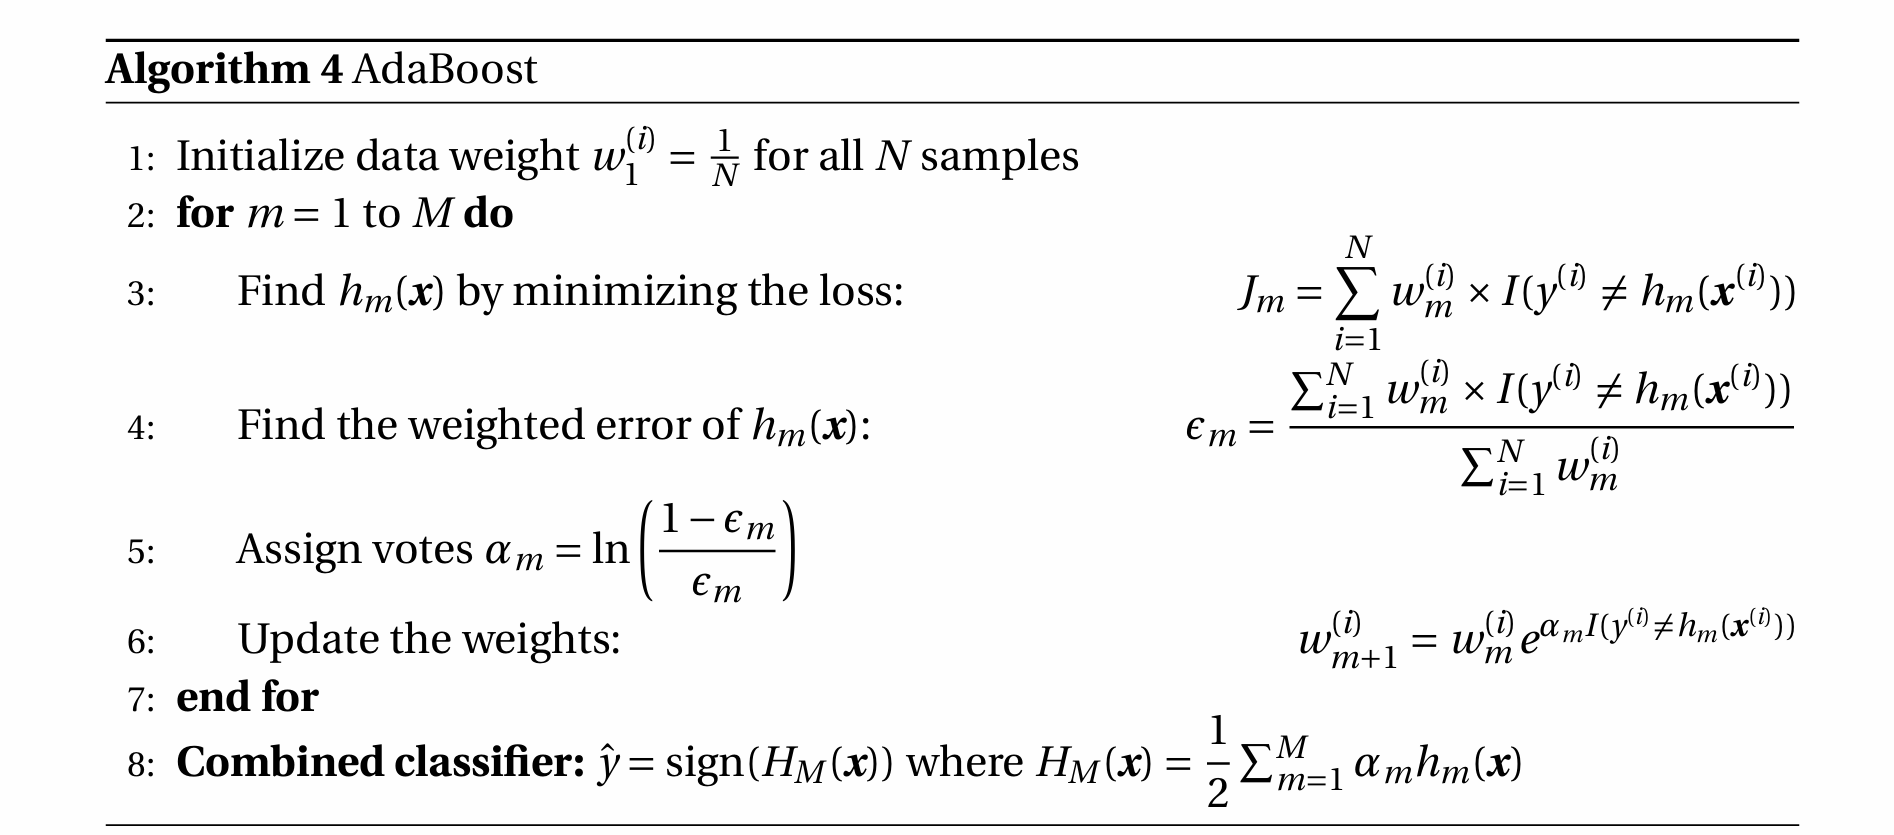
<center>Figure 9: AdaBoost algorithm, ML course, Sharif University</center>

**Now the question is where does the formula of $w_m^{(i)}$ and $\alpha_m$ has come from?**


##### Loss Function:

AdaBoost's loss fucnction is the following exponential loss:
$$\mathscr{L}(y, H_M(x)) = e^{-y \times H_M(x)}$$
$$\hat{y} = sign(H_M(x))$$

The loss function above indicates that if $y$ and $H_M(x)$ have the same sign then $\mathscr{L} = e^{-1} = \frac{1}{e}$ and if not $\mathscr{L} = e$

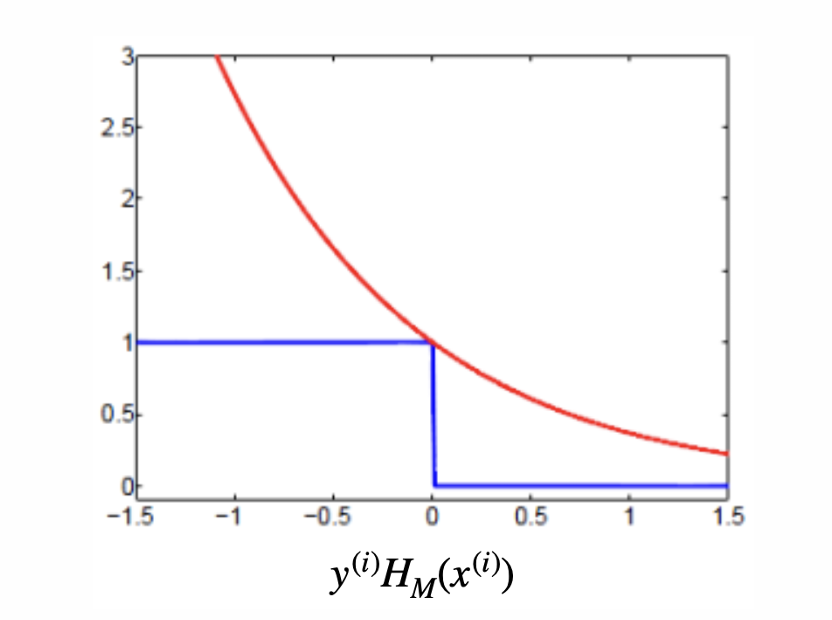
<center>Figure 10: Plot of the two equation above</center>
<br>

+ Now we wanna calculate the exponential loss for $H_M(x)$:
$$H_M(x) = \frac{1}{2} [\alpha_1 h_1(x) + ... + \alpha_m h_m(x)]$$
<center>Adopted from [3]</center>

+ Idea: consider adding the m-th component:

$$\mathscr{L}_m = \sum_{i=1}^{N} e^{-y^{(i)} H_M(x^{(i)})} = \sum_{i=1}^{N} e^{-y^{(i)} [H_{M-1}(x^{(i)}) + \frac{1}{2}\alpha_m h_M(x^{(i)})]}$$

$$ = \sum_{i=1}^{N} e^{-y^{(i)} H_{M-1}(x^{(i)})} e^{\frac{1}{2}\alpha_m h_M(x^{(i)})} = \sum_{i=1}^{N} \underbrace{w_m^{(i)}}_{e^{-y^{(i)} H_{M-1}(x^{(i)})}} e^{\frac{1}{2}\alpha_m h_M(x^{(i)})}$$
<center>Adopted from [3]</center>

Now for finding the ooptimal $h_m(x)$ and $\alpha_m$ We take the derivation of the formula above which is the formula for the loss of the *m*-the model, we calculate the derivation of loss to those variables separately and equal them to zero to find the formula for the optimal decision.

**Deriving the weighted error function**:

$$\mathscr{L}_m = \sum_{i=1}^{N} w_m^{(i)} e^{\frac{1}{2}\alpha_m h_M(x^{(i)})}$$

Now we divide the equation above to sums of classified and misclassified sets:

$$= e^{\frac{-\alpha_m}{2}} (\sum_{\underbrace{y^{(i)} = h_m(x^{(i)})}_{\text{Classified}}} w_m^{(i)}) + e^{\frac{\alpha_m}{2}} (\sum_{\underbrace{y^{(i)} \neq h_m(x^{(i)})}_{\text{Misclassified}}} w_m^{(i)})$$

Now we add and reduce the equation below from the equation above:
$$e^{\frac{-\alpha_m}{2} (\sum_{y^{(i)} \neq h_m(x^{(i)})} w_m^{(i)})}$$

And the following Equation gets generated:

$$(e^{\frac{\alpha_m}{2}} - e^{\frac{-\alpha_m}{2}})\underbrace{(\sum_{y^{(i)} \neq h_m(x^{(i)})} w_m^{(i)})}_{\text{*}} + e^{\frac{-\alpha_m}{2}}\underbrace{(\sum_{i=1}^{N} w_m^{(i)})}_{\text{All the samples}}$$

Now If we wanna get the derivation of the $\mathscr{L}$ to the derivation of $h_m$ We see that only the (*) part of the loss contains $h_m$ and we can derivate it only in that term, So when we wanna optimize $h_m$ we should get the derivation of the equation below to the $h_m$:

$$\text{(*)} \rightarrow J_m = \sum_{i=1}^{N} w_m^{(i)} \times I(y^{(i)} \neq h_m(x^{(i)}))$$

Now we should find a $h_m$ that minimizes the loss above.

**Deriving $\epsilon_m$ and $\alpha_m$ by setting the derivation to zero**:
$$\frac{\partial \mathscr{L}}{\partial \alpha_m} = 0$$

We used the idea of this derivation in the last part to devide into misclassified and correct classified samples:

$$\Rightarrow \frac{1}{2}(e^{\frac{\alpha_m}{2}} + e^{\frac{-\alpha_m}{2}})(\sum_{y^{(i)} \neq h_m(x^{(i)})} w_m^{(i)}) = \frac{1}{2}e^{\frac{-\alpha_m}{2}}(\sum_{i=1}^{N} w_m^{(i)})$$
$$\Rightarrow \frac{e^{\frac{-\alpha_m}{2}}}{(e^{\frac{\alpha_m}{2}} + e^{\frac{-\alpha_m}{2}})} = \underbrace{\frac{(\sum_{y^{(i)} \neq h_m(x^{(i)})} w_m^{(i)})}{\sum_{i=1}^{N} w_m^{(i)}}}_{\epsilon_m}$$

$$\Rightarrow \alpha_m = ln{(\frac{1 - \epsilon_m}{\epsilon_m})}$$
<center>Adopted from [3]</center>


**Now we need to justify the weight update mechanism:**

We have $w_m^{(i)}$ from the first step as: 
$$w_{m+1}^{(i)} = e^{y^{(i)} H_m(x^{(i)})}$$

$$\xRightarrow{\text{seperate} h_m(x^{(i)})} w_{m+1}^{(i)} = w_m^{(i)}e^{-\frac{1}{2} \alpha_m y^{(i)} h_m(x^{(i)})}$$

$$\xRightarrow{y^{(i)} h_m(x^{(i)}) 1-2I(y^{(i)} \neq h_m(x^{(i)}))}  w_{m+1}^{(i)} = w_m^{(i)}e^{-\frac{1}{2} \alpha_m} e^{\alpha_m I(y^{(i)} \neq h_m(x^{(i)}))}$$

Cause $e^{-\frac{1}{2} \alpha_m}$ is independent of $i$ can be ignored:

$$\Rightarrow w_{m+1}^{(i)} = w_m^{(i)}e^{\alpha_m I(y^{(i)} \neq h_m(x^{(i)}))}$$

<center>Adopted from [3]</center>


### Comparison between bagging and boosting:

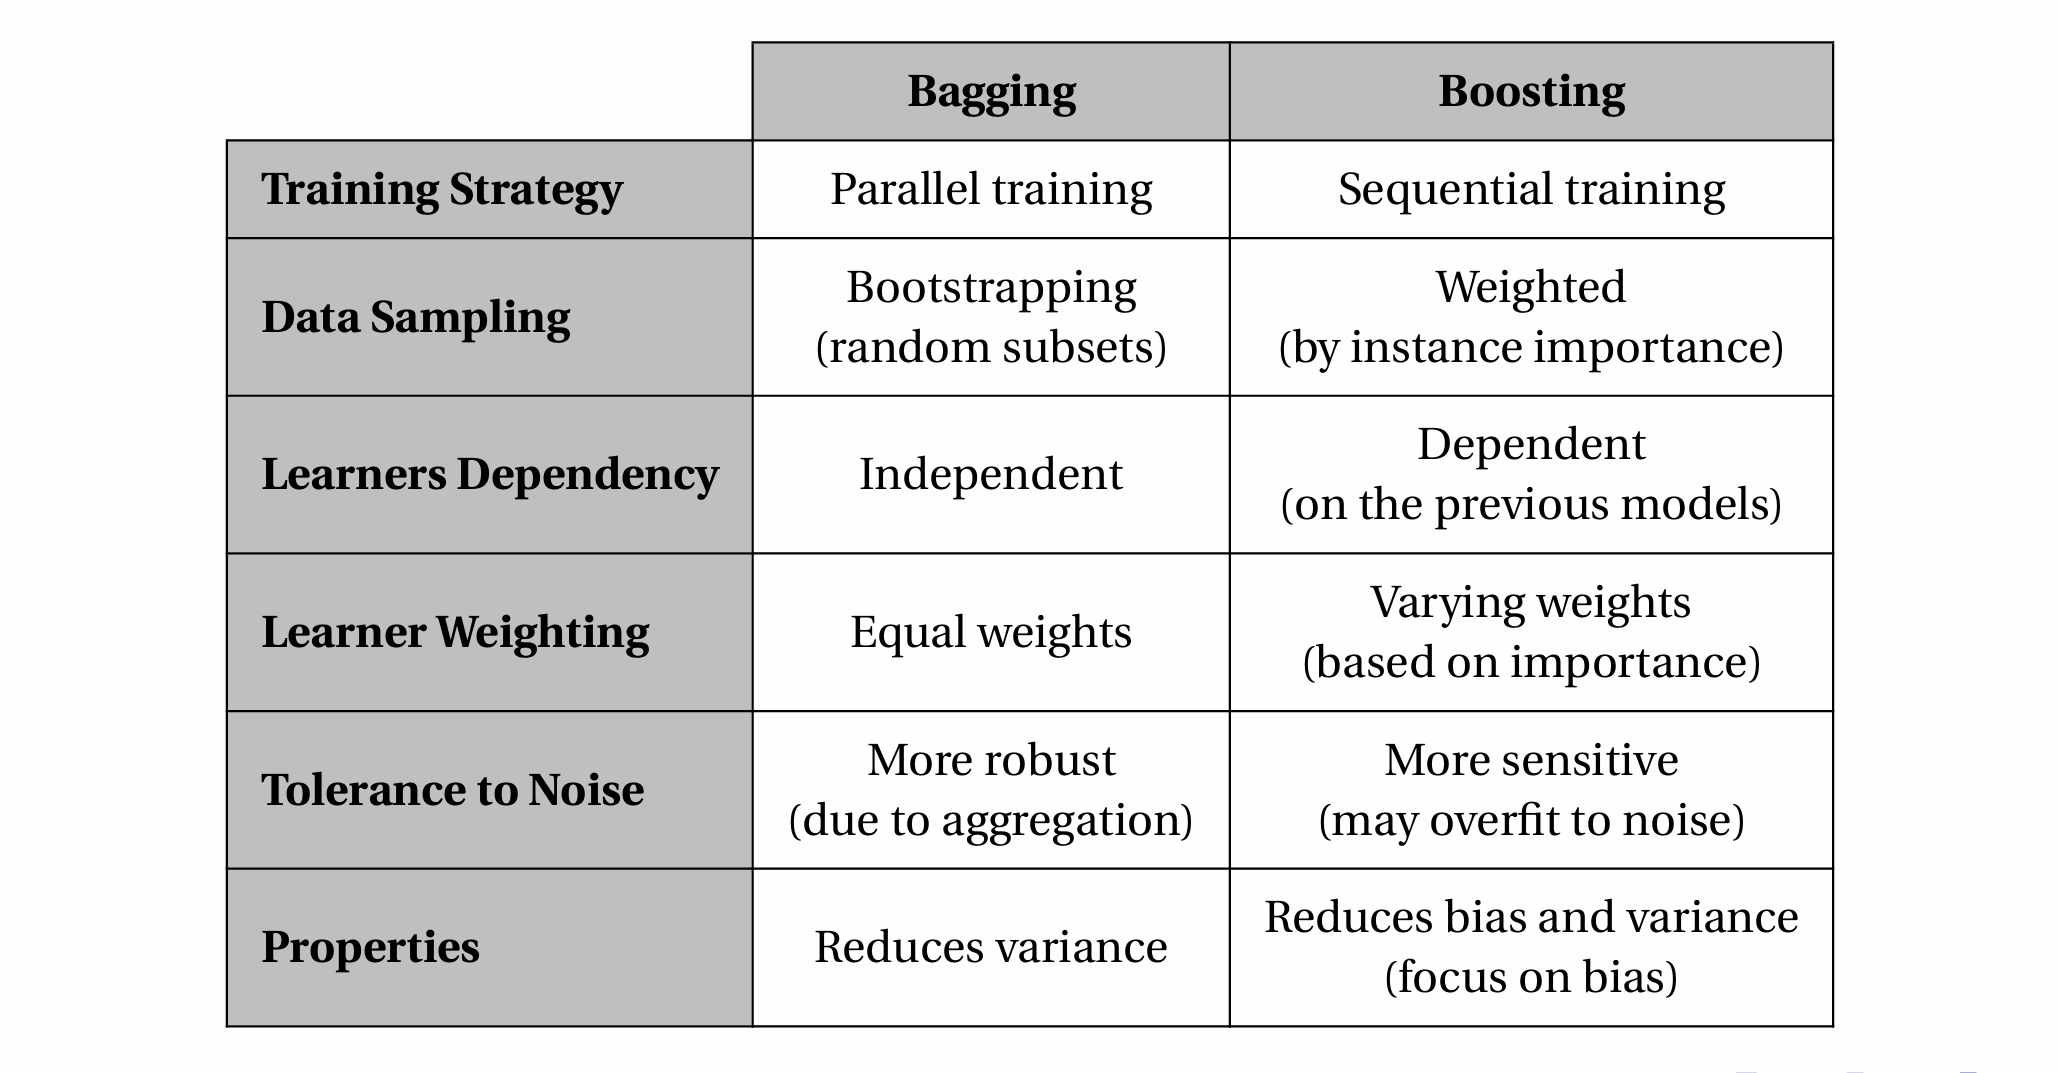
<center>Figure 11: Adopted from [3]</center>

### Refrences:

[1] [Ensemble Learning, IBM](https://www.ibm.com/think/topics/ensemble-learning)<br>
[2] [Random Forrest, IBM](https://www.ibm.com/think/topics/random-forest)<br>
[3] [Ensemble Learning slides, ML course, Sharif university](https://github.com/SharifiZarchi/Introduction_to_Machine_Learning/blob/main/Slides/Chapter_01_Supervised_Learning/05-Ensemble%20Learning/05-Ensemble%20Learning.pdf)<br>
[4] [L. Serrano, Grokking machine learning. NewYork,NY:ManningPublications, Jan. 2022]()<br>
[5] [Decision Stumps, Medium](https://medium.com/geekculture/decision-stump-b8e93c1f54d7)<br>
[6] [Implementing the AdaBoost Algorithm, GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/implementing-the-adaboost-algorithm-from-scratch/)
 